In [40]:
#Lab 07
import numpy as np
import matplotlib.pyplot as plt
import cv2


# FUNCTIONS ----------------------------------------------------------------------------------------
# Both LoadImage and GetSobelFeatures are from assignment 1: modified a bit
def LoadImage(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.float32) / 255.0
    return img

def GetSobelFeatures(img):
    # Compute x and y gradients using Sobel
    Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Gradient magnitude and orientation
    M = np.sqrt(Gx ** 2 + Gy ** 2)
    Theta = np.arctan2(Gy, Gx)  # in radians

    return Gx, Gy, M, Theta

def run_canny_batch(img, thresholds):
    edges = []
    for low, high in thresholds:
        edge = cv2.Canny(img, low, high)
        edges.append(edge)
    return edges

def plot_images_grid(images, titles, cols=4, figsize=(12,6)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def overlay_edges(base_img, edges, color=(255,0,0)):
    overlay = cv2.cvtColor((base_img*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    overlay[edges == 255] = color
    return overlay

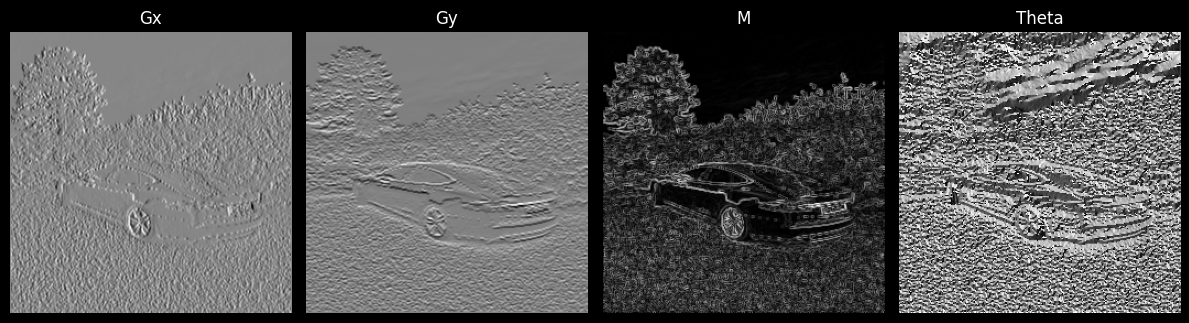

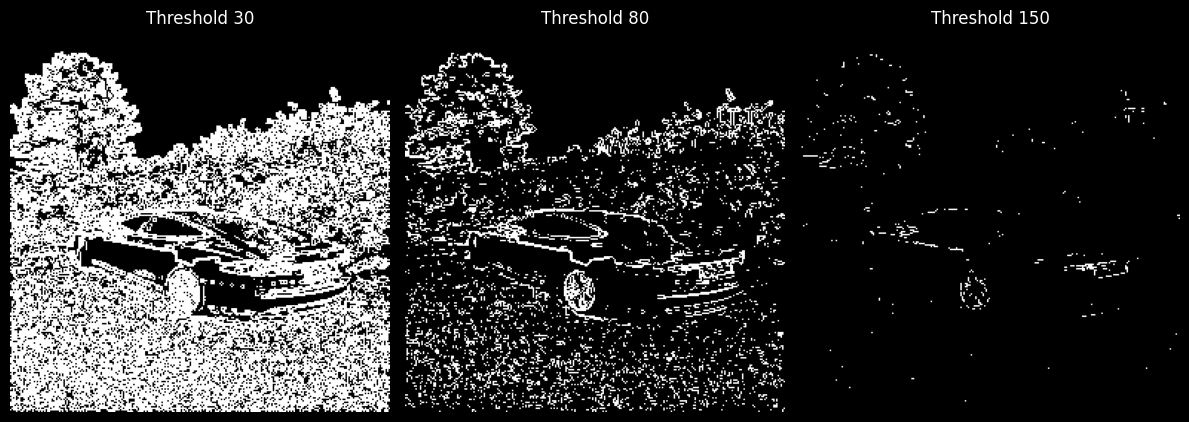

In [45]:
#Exercise 1: PART A -----------------------------------------------------------------------------------------

img = LoadImage('original_image.jpg')
Gx, Gy, M, Theta = GetSobelFeatures(img)
threshold = [30,80,150]

# Normalize for display
Gx = cv2.normalize(Gx, None, 0, 255, cv2.NORM_MINMAX)
Gy = cv2.normalize(Gy, None, 0, 255, cv2.NORM_MINMAX)
M = cv2.normalize(M, None, 0, 255, cv2.NORM_MINMAX)
Theta = cv2.normalize(Theta, None, 0, 255, cv2.NORM_MINMAX)

Gx = Gx.astype(np.uint8)
Gy = (Gy.astype(np.uint8))
M = M.astype(np.uint8)
Theta = Theta.astype(np.uint8)

binary_maps = []
for i,t in enumerate(threshold):
    _, binary = cv2.threshold(M, t, 255, cv2.THRESH_BINARY)
    binary_maps.append(binary)

#Display
plot_images_grid([Gx, Gy, M, Theta], ["Gx", "Gy", "M", "Theta"], cols=4, figsize=(12,6))
plot_images_grid(binary_maps, ["Threshold 30", "Threshold 80", "Threshold 150"], cols=3, figsize=(12,6))

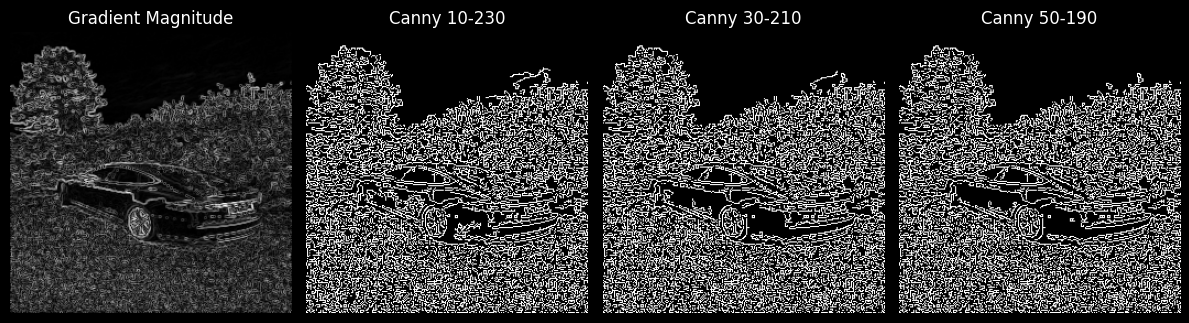

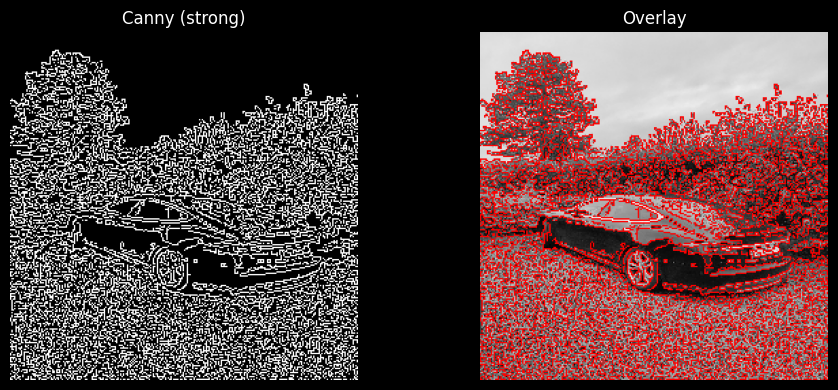

In [42]:
#Exercise 1: PART B 1
# Prepare image once
img_uint8 = (img * 255).astype(np.uint8)

thresholds = [(10,230), (30,210), (50,190)]
edges = run_canny_batch(img_uint8, thresholds)

titles = [f"Canny {low}-{high}" for low, high in thresholds]

plot_images_grid(
    [M] + edges,
    ["Gradient Magnitude"] + titles,
    cols=4,
    figsize=(12,4)
)
overlay_img = overlay_edges(img, edges[-1])

plot_images_grid(
    [edges[-1], overlay_img],
    ["Canny (strong)", "Overlay"],
    cols=2,
    figsize=(10,4)
)


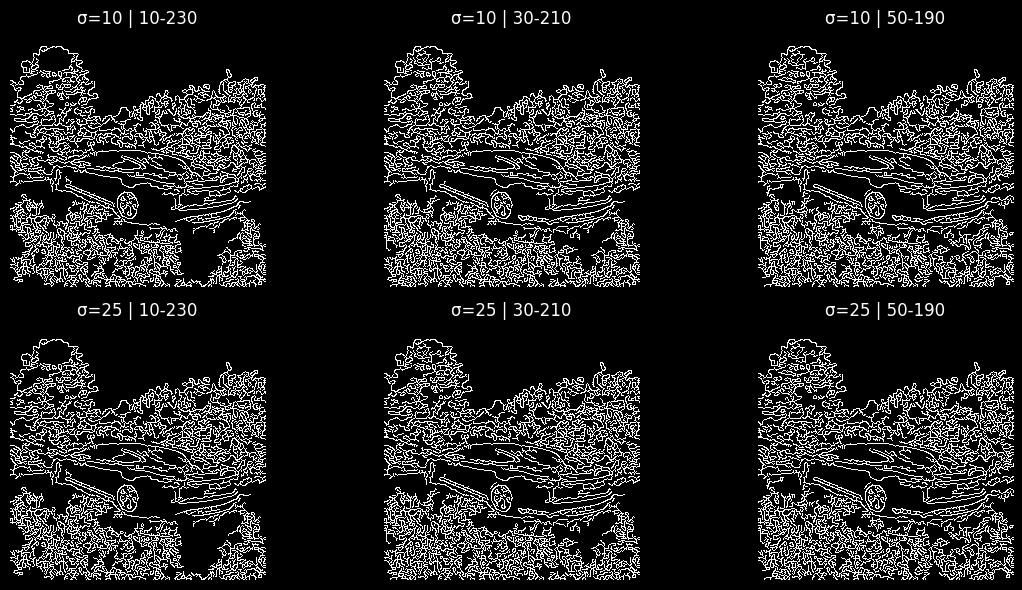

In [43]:
sigmas = [10, 25]
thresholds = [(10,230), (30,210), (50,190)]

all_images = []
all_titles = []

for sigma in sigmas:
    blurred = cv2.GaussianBlur(img, (3,3), sigma)
    blurred = (blurred * 255).astype(np.uint8)

    edges = run_canny_batch(blurred, thresholds)

    for (low, high), edge in zip(thresholds, edges):
        all_images.append(edge)
        all_titles.append(f"σ={sigma} | {low}-{high}")

plot_images_grid(all_images, all_titles, cols=3, figsize=(12,6))